<a href="https://colab.research.google.com/github/Michael-M-William/ML-Final-project/blob/main/Final-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NASA RAW DATA

              
                          │
              
                          ▼
           
                 1. DATA AUDIT
                          │
                          ▼
              2. DATA CLEANING
             - Missing values
             - Invalid values
             - Duplicates
             - IDs / metadata
                          │
                          ▼
              3. DEFINE TARGET
                  pha: N / Y
                          │
                          ▼
             4. TRAIN / VAL / TEST
              70%       15%       15%
               │          │         │
               ▼          ▼         ▼
             TRAIN      VALID      TEST
               │          │         │
               └──────────┴─────────┘
                    NO INFORMATION
                    LEAKAGE BETWEEN
                    SPLITS
                          │
                          ▼
             5. FEATURE ENGINEERING
             Create meaningful orbital
             / physical features
                          │
                          ▼
             6. FEATURE SELECTION
             Select useful features
                          │
                          ▼
             7. PREPROCESSING
             Imputation / Scaling
                          │
                          ▼
             8. PCA EXPERIMENT
             Optional dimensionality
             reduction
                          │
                          ▼
             9. IMBALANCE HANDLING
             ┌────────────┬─────────────┐
             │            │             │
           SMOTE     Class Weight   UnderSampling
             │            │             │
             └────────────┴─────────────┘
                          │
                          ▼
             10. MODEL TRAINING
             LR / SVM / RF / GB /
             XGBoost / etc.
                          │
                          ▼
             11. VALIDATION
             Compare models
                          │
                          ▼
             12. THRESHOLD TUNING
             0.30 / 0.40 / 0.50 / ...
                          │
                          ▼
             13. FINAL MODEL
                          │
                          ▼
             14. TEST ONCE
             Final untouched test set
                          │
                          ▼
             15. FINAL EVALUATION
             Recall / Precision / F1
             ROC-AUC / PR-AUC
             Confusion Matrix




Train

نقدر نعمل عليه:

Imputation
Scaling
Feature Selection
PCA
SMOTE
Class Weight
Undersampling
Model Training


Validation

نستخدمه في:

Model comparison
Threshold tuning
Hyperparameter decisions

لكن لا نعمل عليه SMOTE.

Test

يُترك untouched تمامًا لحد آخر خطوة.

المتغيرات

TARGET

numeric_cols

categorical_cols


# inport lips and data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


In [3]:
df=pd.read_csv('https://gitlab.com/mirsakhawathossain/pha-ml/-/raw/master/Dataset/dataset.csv')

/tmp/ipykernel_1505/3261648306.py:1: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('https://gitlab.com/mirsakhawathossain/pha-ml/-/raw/master/Dataset/dataset.csv')


# EDA

In [4]:
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
print(df.shape)
display(df.head())


(958524, 45)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,albedo,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,58600,20190427.0,J2000,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,2.458239e+06,2.018043e+07,1683.145703,4.608202,1.59478,620.640533,4.819000e-12,1.032800e-11,1.956900e-11,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,59000,20200531.0,J2000,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,2.458321e+06,2.018072e+07,1687.410992,4.619880,1.23429,480.348639,3.193400e-08,4.033700e-09,8.832200e-08,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,59000,20200531.0,J2000,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,2.458446e+06,2.018112e+07,1592.013769,4.358696,1.03429,402.514639,3.052000e-08,3.471800e-09,8.139200e-08,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,58600,20190427.0,J2000,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,2.458248e+06,2.018051e+07,1325.432763,3.628837,1.13948,443.451432,2.332100e-10,1.514300e-09,1.928600e-09,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,59000,20200531.0,J2000,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,2.458926e+06,2.020032e+07,1508.414421,4.129814,1.09575,426.433027,2.373700e-08,3.970900e-09,6.092400e-08,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


In [28]:
ID_COLUMNS = [
    "id",
    "spkid",
    "pdes",
    "name",
    "full_name",
    "orbit_id",
    "epoch_cal",
    "prefix",
    "class"]
existing_id_columns = [
    col for col in ID_COLUMNS
    if col in df.columns]

df = df.drop( columns=existing_id_columns)
print(df.shape)

(958524, 36)


In [23]:
# Target
TARGET = "pha"

# Numerical columns
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

categorical_cols = [col for col in categorical_cols if col != TARGET]

print("Numerical columns:")
print(numeric_cols)
print("\nNumber of numerical columns:", len(numeric_cols))

print("\nCategorical columns:")
print(categorical_cols)
print("\nNumber of categorical columns:", len(categorical_cols))

Numerical columns:
['H', 'diameter', 'albedo', 'diameter_sigma', 'epoch', 'epoch_mjd', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms']

Number of numerical columns: 33

Categorical columns:
['neo', 'equinox']

Number of categorical columns: 2


In [24]:
audit = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    ).round(2),
    "Unique_Values": df.nunique(dropna=True)
})

audit = audit.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(audit)

audit.to_csv(
    "data_quality_report.csv",
    index=True
)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
albedo,float64,823421,85.91,1057
diameter_sigma,float64,822443,85.80,3054
diameter,float64,822315,85.79,16591
pha,object,19921,2.08,2
sigma_om,float64,19922,2.08,223155
sigma_w,float64,19922,2.08,262719
sigma_ma,float64,19922,2.08,266816
sigma_i,float64,19922,2.08,215741
sigma_ad,float64,19926,2.08,269241
sigma_per,float64,19926,2.08,282687


In [31]:

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

print("done")

done


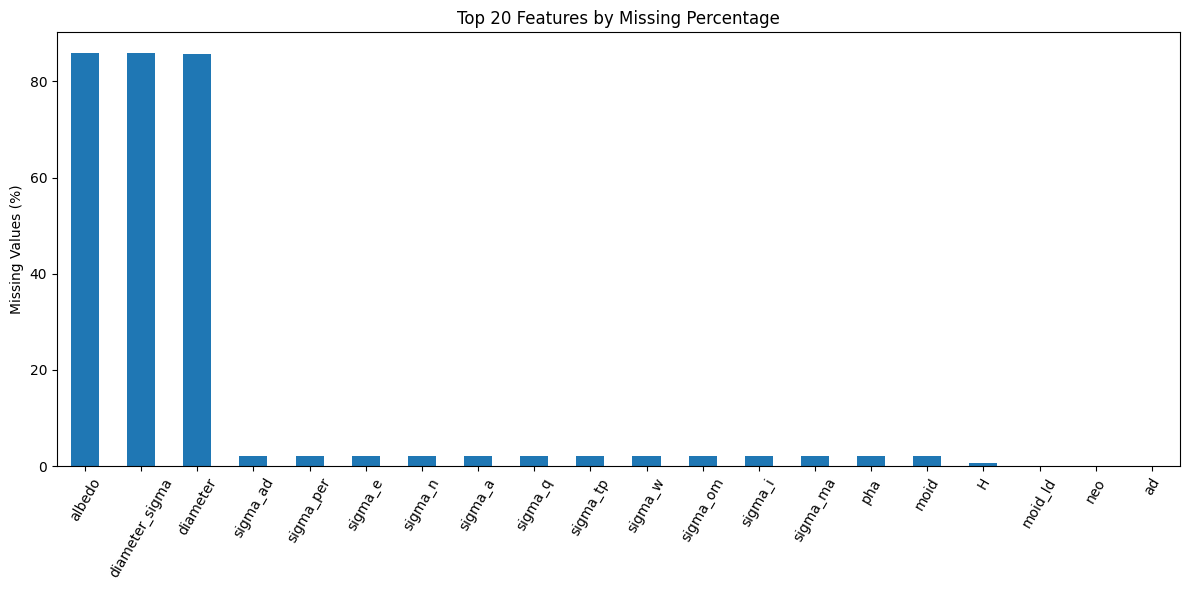

In [32]:
missing_pct = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_pct = missing_pct[
    missing_pct > 0
]

plt.figure(figsize=(12, 6))

missing_pct.head(20).plot(kind="bar")

plt.title("Top 20 Features by Missing Percentage")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [33]:

duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate rows     : {duplicate_count:,}")
print(f"Duplicate %        : {duplicate_percentage:.4f}%")
print(f"Unique rows        : {df.drop_duplicates().shape[0]:,}")

Duplicate rows     : 0
Duplicate %        : 0.0000%
Unique rows        : 958,524


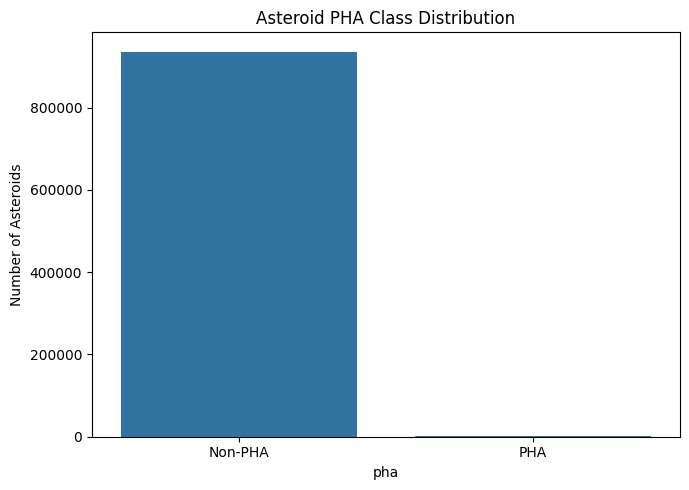

In [36]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=TARGET.index,
    y=TARGET.values
)

# Map 'N' to 'Non-PHA' and 'Y' to 'PHA'
labels = ["Non-PHA" if x == 'N' else "PHA" for x in TARGET.index]
plt.xticks(ticks=range(len(TARGET.index)), labels=labels)
plt.title("Asteroid PHA Class Distribution")
plt.ylabel("Number of Asteroids")

plt.tight_layout()
plt.show()